## ANOVA Hypothesis Testing

We use the one-sided and 5% significance level table is in ANOVA, because we are only interested in testing whether the F-statistic is significantly large, which corresponds to the upper tail of the F-distribution.
24].

In [24]:
!pip install -qqq statsmodels

In [34]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import csv
import os
print(os.getcwd())

C:\Users\HENNY PURWADI\PYTHON\FT_Embed\Text_Embed


In [38]:
# Revised example data where each participant rates both chatbot types
data = {
    'Participant': ['P1', 'P1', 'P2', 'P2', 'P3', 'P3', 'P4','P4','P5','P5'],
    'Chatbot_Type': ['RAG', 'Retrieval-Based', 'RAG', 'Retrieval-Based', 'RAG', 'Retrieval-Based','RAG', 'Retrieval-Based','RAG', 'Retrieval-Based'],
    'Coherence': [8, 6, 7, 5, 9, 7,10,7,9,6],
    'Ambiguity_Handling': [7, 5, 8, 6, 8, 5,10,6,9,5],
    'User_Satisfaction': [9, 6, 8, 7, 9, 7,10,7,9,7]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Save DataFrame to a CSV file
csv_file_path = './data/survey_result.csv'
df.to_csv(csv_file_path, index=False)

csv_file_path

'./data/survey_result.csv'

In [46]:
# Load the CSV file into a DataFrame and display 
df = pd.read_csv('./data/survey_result.csv')
len(df)

10

In [48]:
df.head(10)

,Participant,Chatbot_Type,Coherence,Ambiguity_Handling,User_Satisfaction
0,P1,RAG,8,7,9
1,P1,Retrieval-Based,6,5,6
2,P2,RAG,7,8,8
3,P2,Retrieval-Based,5,6,7
4,P3,RAG,9,8,9
5,P3,Retrieval-Based,7,5,7
6,P4,RAG,10,10,10
7,P4,Retrieval-Based,7,6,7
8,P5,RAG,9,9,9
9,P5,Retrieval-Based,6,5,7


## Manual Calculation of ANOVA for Coherence:

Step-by-Step Calculation of ANOVA:

Calculate the Group Means:
   
RAG Coherence ratings: 8,7,9,10,9.

Mean of RAG for Coherence is (8+7+9+10+9)/5 = 43/5 = 8.6

Retrieval Based Coherence ratings: 6,5,7,7,6.

Mean of Retrieval Based for Coherence is (6+5+7+7+6)/5 = 31/5 = 6.2

Overall Mean = ((8+7+9+10+9) + (6+5+7+7+6))/10 = 7.4

#### Sum of Squares Between Groups (SSB): This measures the variation between the group means and the grand mean.

SSB = n1((Mean1-Grand Mean)^2) + n2((Mean2-Grand Mean)^2)

n1 = 5 (RAG samples)

n2 = 5 (Retrieval-Based samples)

Mean 1 = 8.6 (Mean of RAG)

Mean 2 = 6.2 (Mean of Retrieval-Based)

Overall Mean = 7.4 (Grand Mean)

SSB = 5((8.6 - 7.4)^2) + 5((6.2 - 7.4))^2

SSB = 14.4

#### Sum of Squares Within Groups (SSW): This measures the variation within each group

SSW = \sum_{i=1}^{n_1} (X_{1i} - \bar{X}_1)^2 + \sum_{i=1}^{n_2} (X_{2i} - \bar{X}_2)^2


For RAG: ((8-8.6)^2))+((7-8.6)^2))+((9-8.6)^2))+((10-8.6)^2))+((9-8.6)^2)) = 5.2

For Retrieval-Based: ((6-6.2)^2))+((5-6.2)^2))+((7-6.2)^2))+((7-6.2)^2))+((6-6.2)^2)) = 2.8

SSW = 5.2 + 2.8 

SSW = 8.0




#### Degrees of Freedom (df):

k = number of groups = 2
 
N = total number of observations = 10

Degrees of freedom for the numerator(ν1) = df Between Groups (dfB) = k - 1 = 2-1

dfB = 1

Degrees of freedom for the denominator(ν2) = df Within Groups (dfW) = N - k = 10 - 2 = 8

dfW = 8
 

#### Mean Squares (MS):

MS Between (MSB) = SSB/ dfB = 14.4/1 = 14.4

MS Within (MSW) = SSW/ dfW = 8.0/ 8 = 1.0

#### p-value:
Using F-distribution table, with dfB = 1 and dfW = 8, the F-statistic of 14.4 gives a **p-value = 0.005276** 


### Upper critical values of the F distribution for ν1 numerator degrees of freedom and ν2 denominator degrees of freedom
#### 5% significance level

Heagerty, P., no date. F-Tables. [online] Available at: https://faculty.washington.edu/heagerty/Books/Biostatistics/TABLES/F-Tables/ [Accessed 8 September 2024].

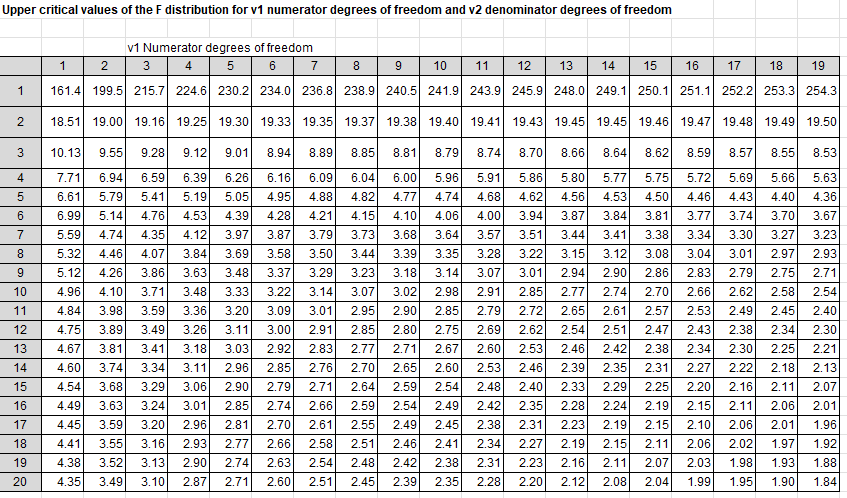

####  The F-critical value is 5.318 for v1 = 1 and v2 = 8 at 5% significance level from the table

#### the F-statistic was 14.4, which is greater than 5.318, meaning that the result is statistically significant, and we can reject the null hypothesis

In [118]:
from scipy.stats import f

# F-statistic, degrees of freedom for numerator and denominator
f_stat = 14.4
v1 = 1  # degrees of freedom for numerator (between groups)
v2 = 8  # degrees of freedom for denominator (within groups)

# Calculate the p-value using the survival function (1 - cumulative distribution function)
p_value = 1 - f.cdf(f_stat, v1, v2)
print(f"p-value: {p_value}")


p-value: 0.005276107935870744


#### Null Hypothesis (H₀) for Coherence:
H₀ (Null Hypothesis): There is no significant difference in the coherence of responses generated by the RAG chatbot and the Retrieval-Based chatbot.

H₀ :μ RAG = μ Retrieval​

In [83]:
# Perform ANOVA for Coherence
model_coherence = ols('Coherence ~ Chatbot_Type', data=df).fit()
anova_table_coherence = sm.stats.anova_lm(model_coherence, typ=2)
print("ANOVA for Coherence:")
print(anova_table_coherence)

ANOVA for Coherence:
              sum_sq   df     F    PR(>F)
Chatbot_Type    14.4  1.0  14.4  0.005276
Residual         8.0  8.0   NaN       NaN


### Interpretation:

F-value (14.4): This is the test statistic that compares the variance between the group means (RAG vs. Retrieval-Based) to the variance within the groups. A higher F-value suggests a larger difference between the group means relative to the variability within each group.

p-value (0.005276): The p-value is the probability of observing such an extreme F-value if the null hypothesis (that both chatbots have the same coherence) were true. A p-value less than 0.05 indicates a statistically significant difference.

Since the p-value is 0.005276, which is much less than 0.05, **we reject the null hypothesis and conclude that there is a significant difference in coherence between the RAG and Retrieval-Based chatbots.**

#### Research Question #3:
Does the RAG Chatbot generate more coherent responses compared to the Retrieval-Based Chatbot, especially when handling nuanced or open-ended queries?

By rejecting H0, we support the Alternative Hypothesis (H1), which is consistent with the answer for research question #3.

**Answer: Yes**, the RAG Chatbot generated more coherent and contextually rich responses compared to the Retrieval-Based Chatbot.

#### Null Hypothesis (H₀) for Ambiguity Handling:
H₀ (Null Hypothesis): There is no significant difference between the RAG Chatbot and the Retrieval-Based Chatbot in handling ambiguous or incomplete queries. Both methods provide equally clear and contextually appropriate responses.

H₀ :μ RAG = μ Retrieval​

In [52]:
# Perform ANOVA for Ambiguity Handling
model_ambiguity = ols('Ambiguity_Handling ~ Chatbot_Type', data=df).fit()
anova_table_ambiguity = sm.stats.anova_lm(model_ambiguity, typ=2)
print("\nANOVA for Ambiguity Handling:")
print(anova_table_ambiguity)


ANOVA for Ambiguity Handling:
              sum_sq   df       F    PR(>F)
Chatbot_Type    22.5  1.0  28.125  0.000725
Residual         6.4  8.0     NaN       NaN


###Interpretation:

F-value (28.125): A high F-value indicates a significant difference between the two methods (RAG and Retrieval-Based) in their ability to handle ambiguous queries.

p-value (0.000725): Since the p-value is far below 0.05, **we reject the null hypothesis (H0). a significant difference in ambiguity handling between the RAG and Retrieval-Based chatbots.**.

The p-value of 0.000725 indicates a statistically significant difference, and the RAG Chatbot’s ability to generate contextually appropriate responses makes it better suited for handling nuanced, ambiguous queries than the Retrieval-Based Chatbot.

The RAG Chatbot provided clearer and more contextually appropriate responses, making it the more effective method for dealing with ambiguity.

#### Research Question #4:
Which method, RAG or Retrieval-Based, is more effective in handling ambiguous or incomplete queries, providing clearer and more contextually appropriate responses
**Answer**: The RAG Chatbot was more effective in handling ambiguous or incomplete queries.
?

#### Null Hypothesis (H₀) for User Satisfaction:
H₀ (Null Hypothesis): TThere is no significant difference in user satisfaction between the RAG Chatbot and the Retrieval-Based Chatbot.

H₀ :μ RAG = μ Retrieval​

In [54]:
# Perform ANOVA for User Satisfaction
model_satisfaction = ols('User_Satisfaction ~ Chatbot_Type', data=df).fit()
anova_table_satisfaction = sm.stats.anova_lm(model_satisfaction, typ=2)
print("\nANOVA for User Satisfaction:")
print(anova_table_satisfaction)


ANOVA for User Satisfaction:
              sum_sq   df          F   PR(>F)
Chatbot_Type    12.1  1.0  34.571429  0.00037
Residual         2.8  8.0        NaN      NaN


### Interpretation:

F-value (34.571): This high F-value indicates a large difference in user satisfaction between the RAG Chatbot and the Retrieval-Based Chatbot.

p-value (0.00037): The p-value is much smaller than 0.05, indicating that we can confidently **reject the null hypothesis (H0) that user satisfaction is equal for both chatbots.** This suggests a statistically significant difference in satisfaction levels between the two.

#### Research Question #5:

Do users report higher overall satisfaction with the RAG Chatbot due to its ability to generate more natural and contextually rich answers, compared to the Retrieval-Based Chatbot?

**Answer**: Yes, users reported higher overall satisfaction with the RAG Chatbot. 